# Importowanie bibliotek

do czyszczenia danych i analizy używamy bibliotek pandas i numpy. 

do wizualizacji użyjemy matplotlib i seaborn

In [297]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [298]:
cacao = pd.read_csv("flavors_of_cacao.csv")

cacao.head()

,Company \n(Maker-if known),Specific Bean Origin\nor Bar Name,REF,Review\nDate,Cocoa\nPercent,Company\nLocation,Rating,Bean\nType,Broad Bean\nOrigin
0,A. Morin,Agua Grande,1876,2016,63%,France,3.75,,Sao Tome
1,A. Morin,Kpime,1676,2015,70%,France,2.75,,Togo
2,A. Morin,Atsane,1676,2015,70%,France,3.00,,Togo
3,A. Morin,Akata,1680,2015,70%,France,3.50,,Togo
4,A. Morin,Quilla,1704,2015,70%,France,3.50,,Peru


# kształt zbioru danych

sprawdzamy shape ze względu na dopełnienie informacji i ewentualne sprawdzenie, czy możemy sobie pozwolić na usunięcie wierszy z brakującymi danymi lub czy musimy uzupełnić te dane

In [299]:
cacao.shape

(1795, 9)

możemy zauważyć, że mamy 1795 wierszy i 9 kolumn, co daje nam dość duży zbiór danych do analizy i otwiera nam furtkę do ewentualnego usunięcia wierszy z brakującymi danymi, jeśli będzie to konieczne.

# Informacje o zbiorze danych

już tutaj widzimy że mamy do czynienia z rozwalonymi nazwami kolumn, które będą wymagały poprawy. dodatkowo sprawdzamy również typy danych, aby upewnić się, że są one odpowiednie do dalszej analizy.

In [300]:
cacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Company 
(Maker-if known)         1795 non-null   object 
 1   Specific Bean Origin
or Bar Name  1795 non-null   object 
 2   REF                               1795 non-null   int64  
 3   Review
Date                       1795 non-null   int64  
 4   Cocoa
Percent                     1795 non-null   object 
 5   Company
Location                  1795 non-null   object 
 6   Rating                            1795 non-null   float64
 7   Bean
Type                         1794 non-null   object 
 8   Broad Bean
Origin                 1794 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 126.3+ KB


In [301]:
cacao.dtypes

Company \n(Maker-if known)            object
Specific Bean Origin\nor Bar Name     object
REF                                    int64
Review\nDate                           int64
Cocoa\nPercent                        object
Company\nLocation                     object
Rating                               float64
Bean\nType                            object
Broad Bean\nOrigin                    object
dtype: object

tutaj widać że 'Cocoa\\nPercent' jest traktowane jako object string i zapisane w formacie tekstowym. W takim razie do wizualizacji i analizy będziemy musieli przekonwertować tę kolumnę na format numeryczny, usuwając znak procenta i zamieniając przecinek na kropkę, aby móc przeprowadzić dalsze analizy statystyczne i wizualizacje.

In [302]:
cacao.describe()

,REF,Review\nDate,Rating
count,1795.000000,1795.000000,1795.000000
mean,1035.904735,2012.325348,3.185933
std,552.886365,2.927210,0.478062
min,5.000000,2006.000000,1.000000
25%,576.000000,2010.000000,2.875000
50%,1069.000000,2013.000000,3.250000
75%,1502.000000,2015.000000,3.500000
max,1952.000000,2017.000000,5.000000


# Sprawdzenie ilości brakujących danych

sprawdzamy ilość brakujących danych, aby zdecydować, czy możemy sobie pozwolić na usunięcie wierszy z brakującymi danymi, czy też musimy uzupełnić te dane, aby zachować jak najwięcej informacji do analizy.

In [303]:
cacao.isnull().sum()

Company \n(Maker-if known)           0
Specific Bean Origin\nor Bar Name    0
REF                                  0
Review\nDate                         0
Cocoa\nPercent                       0
Company\nLocation                    0
Rating                               0
Bean\nType                           1
Broad Bean\nOrigin                   1
dtype: int64

In [304]:
cacao[cacao.isnull().any(axis=1)]

,Company \n(Maker-if known),Specific Bean Origin\nor Bar Name,REF,Review\nDate,Cocoa\nPercent,Company\nLocation,Rating,Bean\nType,Broad Bean\nOrigin
1072,Mast Brothers,Madagascar,999,2012,72%,U.S.A.,2.5,Trinitario,NaN
1544,Soma,"Three Amigos(Chuao, Wild Bolivia, D.R.)",676,2011,70%,Canada,4.0,NaN,"Ven, Bolivia, D.R."


okej... widzimy że mamy 2 kolumny z brakującymi po jednym wierszu, więc myślę, że na spokojnie możemy dropnąć te wiersze, ponieważ nie stracimy zbyt wiele informacji

In [305]:
cacao.dropna(axis=0, inplace=True)

# Zmiana nazw kolumn

w tablicy BETTER_COLUMN_NAMES mamy zdefiniowane nowe nazwy kolumn, które są bardziej czytelne i zgodne z konwencją nazewnictwa w Pythonie.

pozwoli nam to na łatwiejsze czytanie dataframemem

In [306]:
BETTER_COLUMN_NAMES = [
    "company",
    "product_name",
    "reference_id",
    "review_year",
    "cocoa_percent",
    "company_location",
    "rating",
    "bean_type",
    "bean_origin"
]


cacao.columns = BETTER_COLUMN_NAMES

cacao.head()

,company,product_name,reference_id,review_year,cocoa_percent,company_location,rating,bean_type,bean_origin
0,A. Morin,Agua Grande,1876,2016,63%,France,3.75,,Sao Tome
1,A. Morin,Kpime,1676,2015,70%,France,2.75,,Togo
2,A. Morin,Atsane,1676,2015,70%,France,3.00,,Togo
3,A. Morin,Akata,1680,2015,70%,France,3.50,,Togo
4,A. Morin,Quilla,1704,2015,70%,France,3.50,,Peru


In [307]:
cat_cols = ["company", "product_name", "company_location", "bean_type", "bean_origin"]
num_cols = ["reference_id", "review_year", "cocoa_percent", "rating"]

# Zamiana procentów na liczby

tutaj zamieniamy wartości procentowe w kolumnie 'cocoa_percent' na format numeryczny, usuwając znak procenta i zamieniając przecinek na kropkę, aby móc przeprowadzić dalsze analizy statystyczne i wizualizacje.

In [308]:
cacao["cocoa_percent"] = cacao["cocoa_percent"].str.replace("%", "").str.replace(",", ".").astype(float)

cacao["cocoa_percent"]

0       63.0
1       70.0
2       70.0
3       70.0
4       70.0
        ... 
1790    70.0
1791    65.0
1792    65.0
1793    62.0
1794    65.0
Name: cocoa_percent, Length: 1793, dtype: float64

od razu widać różnice. Dodatkowo z własnych obserwacji zauważyłem, że mamy kolumnę 'bean_type', która zawiera puste stringi, którymi trzeba jakoś się zająć

In [309]:
cacao["bean_type"].value_counts()

bean_type
                            887
Trinitario                  418
Criollo                     153
Forastero                    87
Forastero (Nacional)         52
Blend                        41
Criollo, Trinitario          39
Forastero (Arriba)           37
Criollo (Porcelana)          10
Trinitario, Criollo           9
Forastero (Parazinho)         8
Forastero (Arriba) ASS        6
Beniano                       3
Matina                        3
Nacional (Arriba)             3
EET                           3
Criollo (Ocumare 61)          2
Amazon mix                    2
Trinitario, Forastero         2
Amazon, ICS                   2
Criollo (Amarru)              2
Criollo, Forastero            2
Nacional                      2
Forastero (Catongo)           2
Trinitario (85% Criollo)      2
Criollo, +                    1
Criollo (Ocumare 77)          1
Criollo (Ocumare 67)          1
Criollo (Wild)                1
Criollo (Ocumare)             1
CCN51                         

okej pomyślałem żeby wykorzystać KNNImputer do uzupełnienia tych brakujących danych,ale że brakujących jest około 50 % i mamy mało numerycznych kolumn i ciężko będzie sprawdzić korelacje pomiędzy kategorycznymi zmiennymi, to nie ma sensu. Spróbuje Random Forestem coś podziałać

In [310]:
from sklearn.ensemble import RandomForestClassifier

# zmieńmy puste str na nany
cacao = cacao.replace('', np.nan)


# one hot encoding dla kolumn company_location i bean_origin
cacao_encoded = pd.get_dummies(cacao, columns=["company_location", "bean_origin"])


train = cacao_encoded[cacao_encoded['bean_type'].notna()]
test = cacao_encoded[cacao_encoded['bean_type'].isna()]

# wywalamy kolumny, które nie są potrzebne do modelu
X_train = train.drop(columns=['bean_type', 'company', 'product_name', 'reference_id'])
X_test = test.drop(columns=['bean_type', 'company', 'product_name', 'reference_id'])

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

y_train = train['bean_type']


# używamy rf do klasyfikacji brakujących wartości w kolumnie 'bean_type'
from sklearn.ensemble import RandomForestClassifier

#                               n_estimators na 200 żeby nie było za dużo odnóg, bo mamy mało sensownych kolumn
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

bean_type_clean = (
    cacao_encoded["bean_type"]
    .astype("string")
    .str.replace("\u00A0", " ", regex=False)
    .str.strip()
)

# brakujące = NaN lub pusty string (w tym NBSP po czyszczeniu)
missing_mask = bean_type_clean.fillna("").eq("")

if missing_mask.any():
    train = cacao_encoded.loc[~missing_mask]
    test = cacao_encoded.loc[missing_mask]

    X_train = train.drop(columns=["bean_type", "company", "product_name", "reference_id"])
    X_test = test.drop(columns=["bean_type", "company", "product_name", "reference_id"])
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    y_train = train["bean_type"]
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
else:
    preds = np.array([], dtype=object)


preds


array(['Forastero', 'Trinitario', 'Trinitario', 'Trinitario', 'Criollo',
       'Trinitario', 'Forastero (Nacional)', 'Trinitario', 'Trinitario',
       'Forastero (Nacional)', 'Trinitario', 'Trinitario', 'Trinitario',
       'Criollo', 'Forastero (Nacional)', 'Forastero (Nacional)',
       'Criollo', 'Forastero (Nacional)', 'Criollo', 'Criollo',
       'Trinitario', 'Criollo', 'Beniano', 'Criollo', 'Trinitario',
       'Criollo', 'Trinitario', 'Trinitario', 'Criollo', 'Trinitario',
       'Trinitario', 'Nacional (Arriba)', 'Trinitario', 'Trinitario',
       'Criollo', 'Forastero (Arriba)', 'Forastero (Arriba)',
       'Trinitario', 'Trinitario', 'Trinitario', 'Criollo',
       'Forastero (Nacional)', 'Forastero (Nacional)', 'Trinitario',
       'Beniano', 'Criollo', 'Trinitario', 'Criollo', 'Trinitario',
       'Forastero (Nacional)', 'Forastero (Nacional)', 'Trinitario',
       'Criollo, Trinitario', 'Trinitario', 'Amazon mix',
       'Criollo, Trinitario', 'Trinitario', 'Trinitario'

coś jest grubo nie tak... wydają się to losowe predykcje. spróbuje podzielić sensowniej na train i test, żeby zobaczyć czy to coś zmieni i jak wygląda raport klaski, ale najpierw na wszelki wielki wezmę heatmapę korelacji, żeby zobaczyć, czy mamy jakieś silne korelacje między zmiennymi numerycznymi, które mogłyby pomóc w imputacji danych.

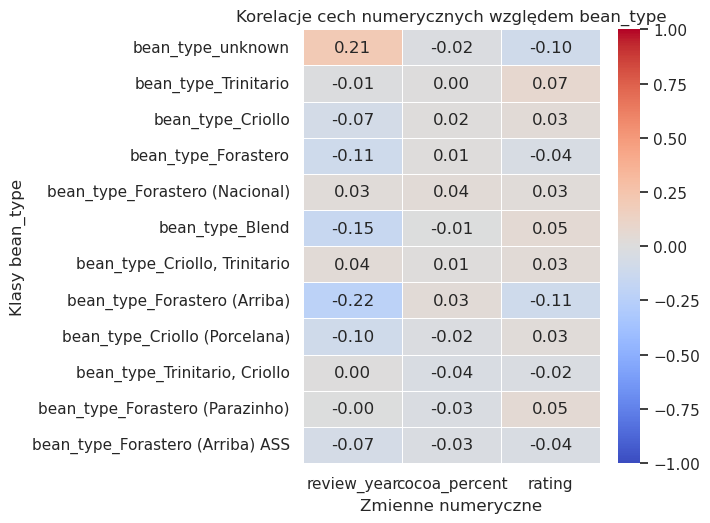

In [311]:
# korelacje zmiennych numerycznych względem bean_type
num_for_corr = [c for c in num_cols if c != "reference_id"]


# szybki cleaning co będzie później robiony ogółem, tutaj prewencyjnie
bean_type_clean = (
    cacao["bean_type"]
    .astype("string")
    .str.replace("\u00A0", " ", regex=False)
    .str.strip()
    .replace("", "unknown")
    .fillna("unknown")
)


# one hot na bean_type, żeby móc policzyć korelacje
bean_type_dummies = pd.get_dummies(bean_type_clean, prefix="bean_type")


# konkatenujemy czyli zlepiamy numeryczne z one hotem i liczymy korelacje,
# potem wybieramy tylko te kolumny, które odpowiadają bean_type
corr_bean_type = (
    pd.concat([cacao[num_for_corr], bean_type_dummies], axis=1)
    .corr()
    .loc[bean_type_dummies.columns, num_for_corr]
)

# dla uproszczenia top 12 klas
top_classes = bean_type_clean.value_counts().head(12).index
top_dummy_idx = [f"bean_type_{cls}" for cls in top_classes]
corr_bean_plot = corr_bean_type.loc[top_dummy_idx]


# heatmapka
plt.figure(figsize=(7, max(4, 0.45 * len(corr_bean_plot))))
sns.heatmap(
    corr_bean_plot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

# jakieś pretty labels od czata
plt.title("Korelacje cech numerycznych względem bean_type")
plt.xlabel("Zmienne numeryczne")
plt.ylabel("Klasy bean_type")
plt.tight_layout()
plt.show()


możemy zauważyć, że no nie ma tu zbytnio z czym pracować. Na logikę nie ma sensu odgadywać typu ziarna na podstawie roku recenzji, procenta kakao czy ratingu... jedyne co widać z tej korelacji to że brak danych może minimalnie korelować ze starszymi recenzjami, ale to jest na tyle słabe, że nie ma sensu tego wykorzystywać do imputacji danych. W takim razie chyba najlepszym rozwiązaniem będzie po prostu usunięcie tych wierszy z brakującymi danymi, ponieważ nie stracimy zbyt wiele informacji, a jednocześnie zachowamy spójność danych do dalszej analizy. Ale żeby już być na 100 procent pewnym, to walne jakiś train test split i zobaczę jak wygląda raport klasyfikacji, żeby mieć pewność, że nie wprowadzam biasu do modelu, który mógłby wynikać z nierównomiernego rozkładu danych w zbiorze treningowym i testowym.

In [312]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

X = X_train
y = y_train

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_tr, y_tr)

y_pred = model.predict(X_val)

print(classification_report(y_val, y_pred, zero_division=0))

                          precision    recall  f1-score   support

                   Blend       1.00      0.40      0.57         5
                   CCN51       0.00      0.00      0.00         1
                 Criollo       0.46      0.52      0.49        25
        Criollo (Amarru)       1.00      1.00      1.00         1
    Criollo (Ocumare 67)       0.00      0.00      0.00         0
     Criollo (Porcelana)       0.00      0.00      0.00         2
     Criollo, Trinitario       1.00      0.40      0.57        10
                     EET       0.00      0.00      0.00         1
               Forastero       0.73      0.65      0.69        17
      Forastero (Arriba)       1.00      0.83      0.91         6
  Forastero (Arriba) ASS       0.00      0.00      0.00         0
     Forastero (Catongo)       0.00      0.00      0.00         1
    Forastero (Nacional)       0.46      0.60      0.52        10
   Forastero (Parazinho)       0.50      0.50      0.50         2
   Forast

67% nie wygląda źle, ale macro avg jest tragiczny... myśle że skoro klasy są niezbalansowane w ogóle, to poddajemy się i po prostu zmienimy puste stringi na 'unknown' i lecimy dalej

In [313]:
y_train.value_counts(normalize=True)

bean_type
Trinitario                  0.461369
Criollo                     0.168874
Forastero                   0.096026
Forastero (Nacional)        0.057395
Blend                       0.045254
Criollo, Trinitario         0.043046
Forastero (Arriba)          0.040839
Criollo (Porcelana)         0.011038
Trinitario, Criollo         0.009934
Forastero (Parazinho)       0.008830
Forastero (Arriba) ASS      0.006623
Beniano                     0.003311
Matina                      0.003311
Nacional (Arriba)           0.003311
EET                         0.003311
Criollo (Ocumare 61)        0.002208
Amazon mix                  0.002208
Trinitario, Forastero       0.002208
Amazon, ICS                 0.002208
Criollo (Amarru)            0.002208
Criollo, Forastero          0.002208
Nacional                    0.002208
Forastero (Catongo)         0.002208
Trinitario (85% Criollo)    0.002208
Criollo, +                  0.001104
Criollo (Ocumare 77)        0.001104
Criollo (Ocumare 67)        

to u góry żeby pokazać jak bardzo rozkład klas jest niezbalansowany

In [314]:
cacao["bean_type"] = cacao["bean_type"].fillna("unknown")

tak jak mówiłem, filluje Nany wpisując unknown

# Normalizacja tekstu


teraz robimy jakąś funkcję, która pozbędzie się typowych problemów ze spacjami, trzeba poszukać jakieś triki, dodatkowo zamierzam użyć regexa dla zwięzłego kodu

In [315]:
from difflib import SequenceMatcher as SM


# usuwa bezsensowne spacje i twarde(ten magic coś to mi czat powiedział),
# dodatkowo stripuje i zamienia za pomocą regexa wiele spacji pomiędzy słowami
n=lambda s:(s.astype("string").str.replace("\u00A0"," ",regex=0)
                         .str.replace(r"\s+"," ",regex=1)
                         .str.strip())

zamiast od razu wykonywać zamierzam ją wykorzystać do ewaluacji wszystkich punktów z instrukcji w jakiejś tabelce, żeby mieć wszystko w jednym miejscu i móc łatwo porównać wyniki przed i po normalizacji tekstu

# Duplikaty

sprawdzamy za pomocą wbudowanego duplicated i szukania kluczowanego duplikatów z powodu natury datasetu, który pozwala mieć np. wiele batonów o tej samej nazwie, ale innym kraju czy też ratingu, więc nie możemy po prostu usunąć duplikatów, ale musimy sprawdzić, które kolumny są kluczowe dla identyfikacji unikalnych rekordów i na tej podstawie zdecydować, czy mamy do czynienia z duplikatami, które można usunąć, czy też z różnymi rekordami o podobnych nazwach.

In [316]:
# pełne wiersze
dup_full = int(cacao.duplicated().sum())
print(dup_full)

if dup_full:
    dup_rows = cacao[cacao.duplicated(keep=False)]
    display(dup_rows.head(20))


# dobra praktyka dynamicznie wymieniać realne kolumny gdyby dodano jakies nowe
key_cols = [
    c for c in [
        "company",
        "product_name",
        "review_year",
        "cocoa_percent",
        "company_location",
        "bean_origin"
    ]
    if c in cacao.columns
]


# sprawdzamy dup po konkretnych kolumnach, bo można mieć np. 2 wiersze tego samego
# produktu tylko z innym ratingiem, czy year
dup_key = int(cacao.duplicated(subset=key_cols).sum())
print(dup_key)

if dup_key:
    show_cols = key_cols + (
        ["reference_id"] if "reference_id" in cacao.columns else []
    )

    dup_key_rows = cacao[
        cacao.duplicated(subset=key_cols, keep=False)
    ][show_cols].sort_values(key_cols)

    display(dup_key_rows.head(30))

0
0


jak widać kolejna syzyfowa praca, ale warto było spróbować

In [317]:

# typowe placeholdery, które mogą oznaczać brak danych
placeholders = {"","na","n/a","none","null","nan","unknown","unk","-","brak"}

rows, variants = [], {}


# lecimy po kategorycznych
for col in cacao.select_dtypes("object"):
    raw = cacao[col].astype("string")
    #normalizacja 
    norm = n(raw)
    norm_l = norm.str.lower()

    # porównanie raw i po normalizacji
    tmp = pd.DataFrame({"raw": raw, "norm": norm}).dropna()
    grp = tmp.groupby("norm")["raw"].nunique()
    inconsistent = grp[grp > 1].index

    # potrzebne później do niespójności
    variants[col] = (
        tmp[tmp["norm"].isin(inconsistent)]
        .drop_duplicates()
        .sort_values(["norm", "raw"])
    )

    rows.append({
        "kolumna": col,
        "unikalne_wartosci_surowe": int(raw.nunique(dropna=True)),
        "unikalne_wartosci_po_normalizacji": int(norm_l.nunique(dropna=True)),

        "liczba_nbsp": int(raw.str.contains("\u00A0", na=False).sum()),
        #                                       regex dla spacji na początku lub końcu
        "liczba_spacji_na_brzegach": int(raw.str.contains(r"^\s+|\s+$", na=False).sum()),
        #                                      regex dla dwóch lub więcej spacji obok siebi
        "liczba_wielokrotnych_spacji": int(raw.str.contains(r"\s{2,}", na=False).sum()),

        "liczba_placeholderow": int(norm_l.isin(placeholders).sum()),
        "liczba_niespojnych_grup": int(len(inconsistent)),
    })

report = pd.DataFrame(rows).sort_values(
    ["liczba_niespojnych_grup", "liczba_placeholderow"],
    ascending=[False, False]
)

print()
display(report)

,kolumna,unikalne_wartosci_surowe,unikalne_wartosci_po_normalizacji,liczba_nbsp,liczba_spacji_na_brzegach,liczba_wielokrotnych_spacji,liczba_placeholderow,liczba_niespojnych_grup
3,bean_type,41,41,887,887,0,887,0
4,bean_origin,99,99,73,73,0,73,0
0,company,416,416,0,0,0,0,0
1,product_name,1038,1037,0,0,0,0,0
2,company_location,60,60,0,0,0,0,0


dobra, spacje były dobrym pomysłem, 887 zmian po normalizacji jest spoko wynikiem. a wieć zaaplikujmy te miany

In [318]:
cacao[cat_cols] = cacao[cat_cols].apply(n)

# for dla kolumn z czata stąd jakieś dziwne rzeczy, ale generalnie działa
for col in cacao.select_dtypes(include=["string", "object"]).columns:
    s = cacao[col].astype("string")
    print(
        f"{col}: "
        f"NBSP={int(s.str.contains('\u00A0', na=False).sum())}, "
        f"edge_ws={int(s.str.contains(r'^\s+|\s+$', na=False).sum())}, "
        f"multi_ws={int(s.str.contains(r'\s{2,}', na=False).sum())}"
    )

company: NBSP=0, edge_ws=0, multi_ws=0
product_name: NBSP=0, edge_ws=0, multi_ws=0
company_location: NBSP=0, edge_ws=0, multi_ws=0
bean_type: NBSP=0, edge_ws=0, multi_ws=0
bean_origin: NBSP=0, edge_ws=0, multi_ws=0


cudnie, już nie ma problemu ze spacjami, przejdźmy dalej

# Niespójności w danych

czyli różne zapisy tego samego. Sprawdzaliśmy to już w ostatniej pętli, także tutaj tylko zewaluujemy wyniki

In [319]:
print(variants.items())

dict_items([('company', Empty DataFrame
Columns: [raw, norm]
Index: []), ('product_name', Empty DataFrame
Columns: [raw, norm]
Index: []), ('company_location', Empty DataFrame
Columns: [raw, norm]
Index: []), ('bean_type', Empty DataFrame
Columns: [raw, norm]
Index: []), ('bean_origin', Empty DataFrame
Columns: [raw, norm]
Index: [])])


jak widać brak jakichkolwiek niespójności w danych, więc lecimy dalej

# Literówki

wykorzystamy SequenceMatcher do sprawdzania podobieństwa stringów, żeby znaleźć potencjalne literówki w danych. Sprawdzimy to na kolumnach kategorycznych, które mogą zawierać takie literówki, takich jak 'company', 'product_name', 'company_location', 'bean_type', 'bean_origin'. Zacznijmy od szybkiego pipa jak nie mamy libki

In [320]:
from difflib import SequenceMatcher

In [321]:
def typos(s, min_count=2, sim_min=0.85):
    s = s.astype(str).str.strip()
    s = s[s.str.len() > 0]
    s = s[s != "nan"]

    cnt = s.value_counts()

    # common czyli coś co tam pojawia się min razy czyli takie kanoniczne wart
    common = cnt[cnt >= min_count].index.tolist()
    # rare to wszystko poniżej progu, czyli potencjalne literówki, które warto sprawdzić
    rare   = cnt[cnt <  min_count].index.tolist()

    if not common or not rare:
        return pd.DataFrame()

    results = []
    for r in rare:
        # best_match to best literówka
        best_match, best_score = max(
            # lecimy po common i sprawdzamy podob do r, czyli potencjalną literówkę
            ((c, SequenceMatcher(None, r.lower(), c.lower()).ratio())
             for c in common),
            key=lambda x: x[1],
            default=(None, 0),
        )
        # jeśli najlepsza jest git, to dodajemy
        if best_match and best_score >= sim_min:
            results.append({
                "rare":    r,
                "match":   best_match,
                "sim":     round(best_score, 3),
                "n_rare":  int(cnt[r]),
                "n_match": int(cnt[best_match]),
            })
    if not results:
        return pd.DataFrame()
    df = pd.DataFrame(results).sort_values("sim", ascending=False)
    df = df.drop_duplicates(subset=["rare"])
    return df


cat_cols = cacao.select_dtypes(include=["string", "object"]).columns
correction_maps = {}

for col in cat_cols:
    try:
        typos_df = typos(cacao[col], min_count=2, sim_min=0.85)
    except Exception:
        continue

    if typos_df.empty:
        continue

    correction_maps[col] = dict(zip(typos_df["rare"], typos_df["match"]))
    print(f"{col}, len {len(typos_df)} ")
    print(typos_df.to_string(index=False))



company, len 5 
                                  rare                                  match   sim  n_rare  n_match
                       Cacao de Origin                        Cacao de Origen 0.933       1        6
   Heirloom Cacao Preservation (Mindo) Heirloom Cacao Preservation (Guittard) 0.877       1        4
   Heirloom Cacao Preservation (Manoa)   Heirloom Cacao Preservation (Zokoko) 0.873       1        2
Heirloom Cacao Preservation (Fruition) Heirloom Cacao Preservation (Guittard) 0.868       1        4
                               Xocolat                                Xocolla 0.857       1        2
product_name, len 19 
                                    rare                                match   sim  n_rare  n_match
    Camino Verde P., Balao, Guayas, 2012 Camino Verde P., Balao, Guayas, 2014 0.972       1        2
    Camino Verde P., Balao, Guayas, 2013 Camino Verde P., Balao, Guayas, 2014 0.972       1        2
                       Papaua New Guinea             

dobra, mamy ładny output, który pokazuje potencjalne literówki w danych. Sam widzę już tutaj paru kandydatów, ale najlepiej będzie to przepuścić przez ai i niech sama zdecyduje, które z tych potencjalnych literówek są rzeczywiście literówkami, a które mogą być poprawnymi, ale rzadziej występującymi wartościami.

In [322]:

# przefiltrowane przez ai i ręcznie sprawdzone przeze mnie literówki do zmiany
corrections = {
    "company": {
        "Cacao de Origin": "Cacao de Origen",
    },
    "product_name": {
        "Papaua New Guinea":  "Papua New Guinea",
        "Venzuela":           "Venezuela",
        "Nicaraqua":          "Nicaragua",
        "Grenade":            "Grenada",
        "Trinidad-Tobago":    "Trinidad & Tobago",
        "Dos Rios":           "Los Rios",
        "Chiapan":            "Chiapas",
    },
    "company_location": {
        "Niacragua": "Nicaragua",
        "Eucador":   "Ecuador",
    },
    "bean_type": {
        "Forastero (Arriba) ASSS": "Forastero (Arriba) ASS",
    },
    "bean_origin": {
        "Trinidad-Tobago": "Trinidad, Tobago",
    },
}

for col, mapping in corrections.items():
    before = cacao[col].value_counts()
    cacao[col] = cacao[col].replace(mapping)
    for old, new in mapping.items():
        n = cacao[col].eq(new).sum()
        print(f"  [{col}] '{old}' - '{new}'  (teraz: {n})")


  [company] 'Cacao de Origin' - 'Cacao de Origen'  (teraz: 7)
  [product_name] 'Papaua New Guinea' - 'Papua New Guinea'  (teraz: 16)
  [product_name] 'Venzuela' - 'Venezuela'  (teraz: 22)
  [product_name] 'Nicaraqua' - 'Nicaragua'  (teraz: 10)
  [product_name] 'Grenade' - 'Grenada'  (teraz: 12)
  [product_name] 'Trinidad-Tobago' - 'Trinidad & Tobago'  (teraz: 3)
  [product_name] 'Dos Rios' - 'Los Rios'  (teraz: 7)
  [product_name] 'Chiapan' - 'Chiapas'  (teraz: 3)
  [company_location] 'Niacragua' - 'Nicaragua'  (teraz: 6)
  [company_location] 'Eucador' - 'Ecuador'  (teraz: 55)
  [bean_type] 'Forastero (Arriba) ASSS' - 'Forastero (Arriba) ASS'  (teraz: 7)
  [bean_origin] 'Trinidad-Tobago' - 'Trinidad, Tobago'  (teraz: 3)


# Która czekolada jest gorzka

Teraz sprawdzimy która czekolada w batonie jest gorzka, wygooglowałem, że według standardu przyjmuje się że gorzkie czekolady zaczynają się od 70 procent, więc tak zrobimy

In [323]:
cacao["is_dark"] = cacao["cocoa_percent"] >= 70

# Skala oceny według klucza z instrukcji

według instrukcji robimy prosty pd.cut z przedziałami zamkniętymi po prawej

In [324]:

bins   = [0, 1, 2, 3, 4, 5]
labels = ["Nieprzyjemny", "Rozczarowujący", "Poprawny", "Premium", "Elita"]

cacao["rating_grade"] = pd.cut(
    cacao["rating"],
    bins=bins,
    labels=labels,
    right=True,          # prawostronnie domkniete
    include_lowest=True  # żeby rating == 1.0 nie wypadł poza zakres
)

# Wizualizacja danych

teraz możemy zwizualizować sobie dane, oprócz jakichś tam losowych obserwacji i zwykłego baru z licznością zrobimy kilka innych fajnych plotów

In [325]:
sns.set_theme(style="darkgrid", palette="muted")
BROWN = "#6B3A2A"
fig_kw = dict(facecolor="#FDF6EC")

## Gorzka vs mleczna i liczność recenzji

za pomocą barplotów możemy zobaczyć, jak rozkładają się oceny dla gorzkich i mlecznych czekolad, a także ile recenzji przypada na każdą z tych kategorii

/tmp/ipykernel_3317882/1414185898.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")


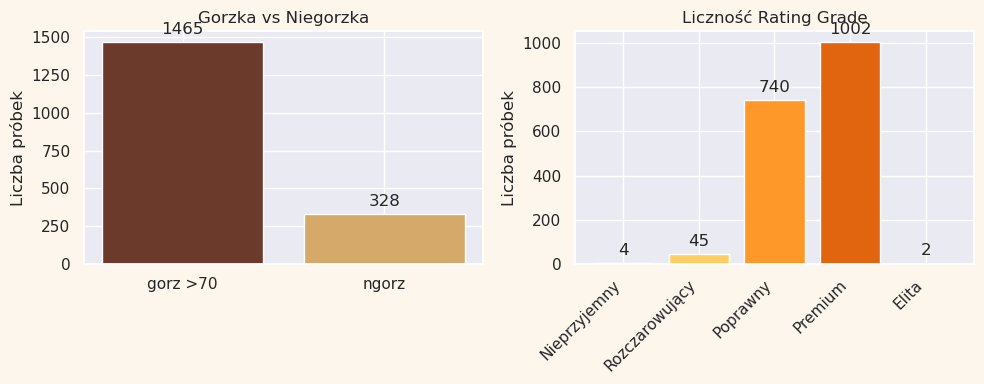

In [326]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor="#FDF6EC")


counts_dark = cacao["is_dark"].value_counts().rename({True: "gorz >70", False: "ngorz"})
axes[0].bar(counts_dark.index, counts_dark.values, color=[BROWN, "#D4A96A"], edgecolor="white")
axes[0].bar_label(axes[0].containers[0], padding=4)
axes[0].set(title="Gorzka vs Niegorzka", ylabel="Liczba próbek")

counts_grade = cacao["rating_grade"].value_counts().sort_index()
axes[1].bar(counts_grade.index, counts_grade.values,
            color=sns.color_palette("YlOrBr", len(counts_grade)), edgecolor="white")
axes[1].bar_label(axes[1].containers[0], padding=4)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")
axes[1].set(title="Liczność Rating Grade", ylabel="Liczba próbek")

plt.tight_layout()
plt.show()

widzimy że większość to gorzkie czekolady, a jeśli chodzi o oceny, to mało elit i nieprzyjemnych, co może oznaczać, że oznaczenie premium nie ma nic wspólnego z oceną i jest bezsensowną etykietą

## top 12 krajów recenzji + oceny

przyjrzyjmy się jak ma się ilość recenzji z danego kraju do ocen, które te recenzje otrzymały.

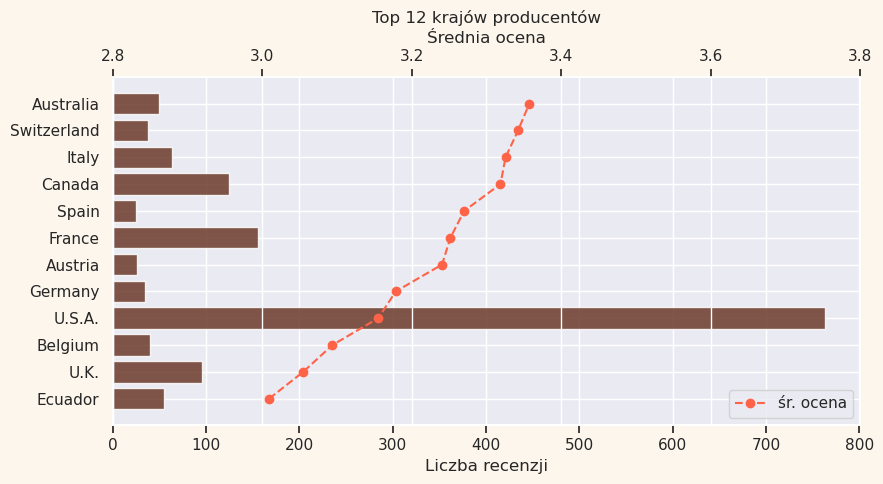

In [327]:
top_loc = (
    cacao.groupby("company_location")
    .agg(n=("rating", "count"), avg_rating=("rating", "mean"))
    .nlargest(12, "n")
    .sort_values("avg_rating", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5), **fig_kw)
bars = ax.barh(top_loc.index, top_loc["n"], color=BROWN, alpha=0.85)
ax2 = ax.twiny()
ax2.plot(top_loc["avg_rating"], top_loc.index,
         "o--", color="tomato", lw=1.5, ms=6, label="śr. ocena")
ax2.set(xlabel="Średnia ocena", xlim=(2.8, 3.8))
ax2.legend(loc="lower right")
ax.set(title="Top 12 krajów producentów", xlabel="Liczba recenzji")
plt.tight_layout()
plt.show()

możemy zobaczyć że USA jest liderem liczby recenzji, ale oceny są rozłożone dość równomiernie, podczas gdy inne kraje mają mniej recenzji, ale często wyższe oceny, co może sugerować różnice w preferencjach smakowych lub w sposobie oceniania czekolad w różnych krajach... albo to może być tylko kwestia datasetu

## Gorzkość batona a rating
Sprawdzimy jak wygląda rozkład ocen w zależności od gorzkości batona, aby zobaczyć, czy istnieje jakaś korelacja między tymi dwoma zmiennymi.

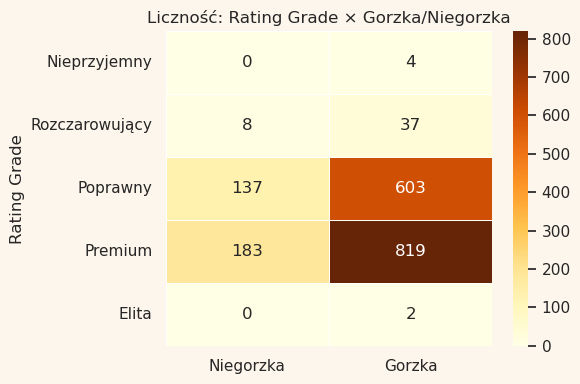

In [328]:
heat = (
    cacao.groupby(["rating_grade", "is_dark"], observed=True)
    .size()
    .unstack("is_dark")
    .rename(columns={False: "Niegorzka", True: "Gorzka"})
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(6, 4), **fig_kw)
sns.heatmap(heat, annot=True, fmt="d", cmap="YlOrBr",
            linewidths=0.5, ax=ax)
ax.set(title="Liczność: Rating Grade × Gorzka/Niegorzka",
       xlabel="", ylabel="Rating Grade")
plt.tight_layout()
plt.show()

na plocie widać, że gorzkie czekolady dostają dużo więcej recenzji niż mleczne, co może sugerować, że są one bardziej popularne wśród recenzentów, ale oceny dla obu kategorii są dość podobne, co może oznaczać, że gorzkość nie jest głównym czynnikiem wpływającym na ocenę czekolady.

# Mała poprawka
podczas czyszczenia danych zauważyłem, że w kolumnie 'bean_origin' mamy wartość 'Madagascar', która jest zapisana z dużą literą, podczas gdy inne wartości są zapisane małymi literami. Aby zachować spójność danych, zmienię tę wartość na 'madagascar'.

In [332]:
cacao["bean_origin"] = cacao["bean_origin"].replace({"Madagascar": "madagascar"})

dodatkowo podczas sprzątania danych zmienialiśmy dtype z object na string, więc warto to poprawić, bo scikitlearn nie lubi tego typu i będzie tragedia podczas dłubania modeli

In [330]:
str_cols = cacao.select_dtypes(include="string").columns
cacao[str_cols] = cacao[str_cols].astype(object)

print(cacao.dtypes)

company               object
product_name          object
reference_id           int64
review_year            int64
cocoa_percent        float64
company_location      object
rating               float64
bean_type             object
bean_origin           object
is_dark                 bool
rating_grade        category
dtype: object


# Zapis do csv
na koniec zapisujemy nasz posprzątany datasecik do csv i mamy spokój

In [331]:
out_path = "flavors_of_cacao_clean.csv"
cacao.to_csv(out_path, index=False, encoding="utf-8-sig")
# tutaj taki myk co kiedyś się dowiedziałem, że encoding utf-8-sig sprawia że Excel na
# naszym kochanym windowsie poprawnie otwierał polskie znaki
